# Swiggy Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#### Load Data

In [2]:
df = pd.read_excel("swiggy_data.xlsx")

In [5]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [6]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


#### No. Of Rows And Columns

In [8]:
df.shape

(197430, 10)

In [14]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


#### Information about data

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


### Total Sales

In [13]:
Total_Sales = df['Price (INR)'].sum()
print("Total Sales:", round(Total_Sales, 2))

Total Sales: 53012505.77


### Average Rating

In [15]:
Average_Rating = df['Rating'].mean()
print("Average Rating:", round(Average_Rating, 2))

Average Rating: 4.34


### Average Order Value

In [16]:
Avg_Order_Value = df['Price (INR)'].mean()
print("Average Order Value:", round(Avg_Order_Value, 2))

Average Order Value: 268.51


### Rating Count

In [17]:
Rating_Count = df['Rating'].sum()
print("Total Ratings:", Rating_Count)

Total Ratings: 857158.5


# Charts

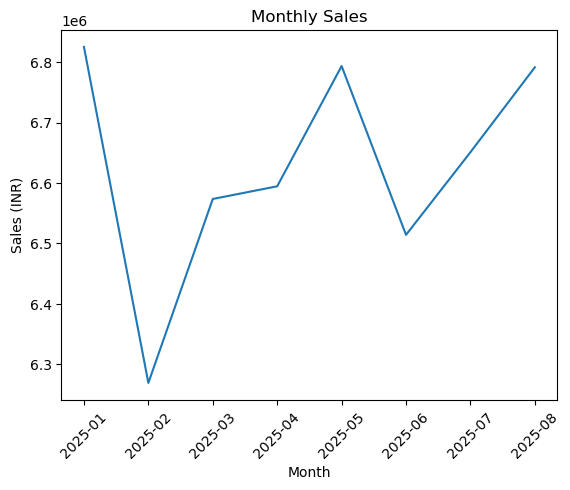

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Month'] = df['Order Date'].dt.to_period('M').astype(str)

Monthly_Sales = df.groupby('Order Month')['Price (INR)'].sum().reset_index()

plt.figure()

plt.plot(Monthly_Sales['Order Month'], Monthly_Sales['Price (INR)'])
plt.title('Monthly Sales')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Sales (INR)')
plt.show()


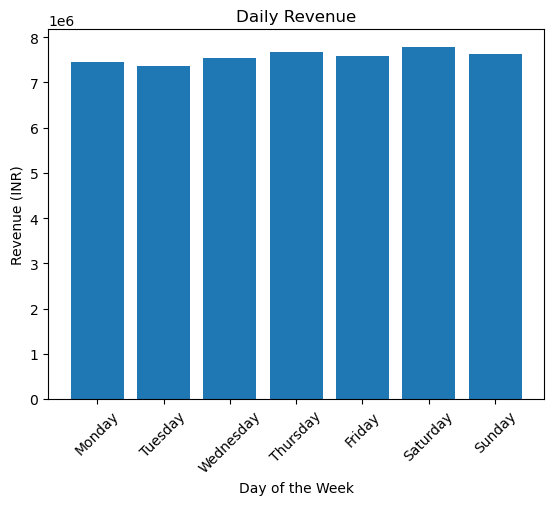

In [6]:
df['Day Name'] = df['Order Date'].dt.day_name()

Daily_Revenue = df.groupby('Day Name')['Price (INR)'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure()
plt.bar(Daily_Revenue.index, Daily_Revenue.values)

plt.title('Daily Revenue')
plt.xlabel('Day of the Week')
plt.xticks(rotation=45)
plt.ylabel('Revenue (INR)')
plt.show()

In [8]:
Non_veg_keywords = ['chicken', 'mutton', 'fish', 'egg', 'prawn', 'pork', 'beef','non-veg','non veg','biryani','kabab','kebab']

df['Food Category'] = np.where(
    df['Dish Name'].str.lower().str.contains('|'.join(Non_veg_keywords)), 'Non-Veg', 'Veg'
)



In [9]:
Food_Revenue = df.groupby('Food Category')['Price (INR)'].sum().reset_index()

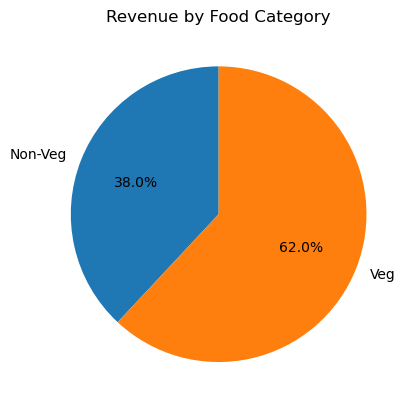

In [10]:
plt.figure()
plt.pie(Food_Revenue['Price (INR)'], labels=Food_Revenue['Food Category'], autopct='%1.1f%%', startangle=90)
plt.title('Revenue by Food Category')
plt.show()


### Sales By State

In [3]:
figure = px.bar(
    df.groupby('State',as_index=False)['Price (INR)'].sum()
      .sort_values('Price (INR)', ascending=False),

    x='Price (INR)',
    y='State',
    orientation='h', 
    title='Revenue by State'
)
figure.show()

### Quarterly Sales

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

Quarterly_Summary =(
     df.groupby('Quarter', as_index=False).agg(
    Total_Sales =( 'Price (INR)',"sum"),
    Avg_Rating = ('Rating',"mean"),
    Total_Orders = ('Price (INR)',"count")
)
.sort_values('Quarter')
)
Quarterly_Summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667821.77,4.342643,73096
1,2025Q2,19902256.59,4.340011,74163
2,2025Q3,13442427.41,4.342359,50171


### Top 5 Cities By Sales

In [5]:
top_5_cities =( df.groupby("City")['Price (INR)']
.sum()
.nlargest(5)
.sort_values()
.reset_index()
)

fig = px.bar(
    top_5_cities,
    x='Price (INR)',
    y='City',
    orientation='h',
    title='Top 5 Cities by Sales'
)

fig.show()

### Weekly Trend of Sales

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Week'] = df['Order Date'].dt.isocalendar().week

df_weekly_sales = df.groupby('Week')['Price (INR)'].sum().reset_index()

fig = px.line(
    df_weekly_sales,
    x='Week',
    y='Price (INR)',
    title='Weekly Sales Trend'
)
fig.show()